## 1.  Import Libraries

In [1]:
# ── Core ────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Preprocessing ────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Models ───────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# ── Model Selection ──────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    KFold,
    TimeSeriesSplit,
    cross_val_score,
    GridSearchCV,
)
from sklearn.pipeline import make_pipeline

# ── Metrics ──────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Time-Series ──────────────────────────────────
from statsmodels.tsa.stattools import adfuller

# ── Misc ─────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Style ────────────────────────────────────────
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("All libraries loaded successfully!")


All libraries loaded successfully!


---
## 2. Data Loading & Initial Inspection

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [3]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print(f"    Dataset loaded | Shape: {df.shape}")
print(f"    Rows : {df.shape[0]:,}")
print(f"    Cols : {df.shape[1]}")
print(f"\nColumns:\n{df.columns.tolist()}")


    Dataset loaded | Shape: (2640, 12)
    Rows : 2,640
    Cols : 12

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [4]:
df.head(10)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [5]:
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
print("=" * 60)
print("STATISTICAL SUMMARY (transposed)")
print("=" * 60)
df.describe().T.style.background_gradient(cmap="Blues")


STATISTICAL SUMMARY (transposed)


,count,mean,std,min,25%,50%,75%,max
Year,2640.000000,2020.000000,3.162877,2015.000000,2017.000000,2020.000000,2023.000000,2025.000000
Month,2640.000000,6.500000,3.452707,1.000000,3.750000,6.500000,9.250000,12.000000
Estimated_Deliveries,2640.000000,9922.199621,3935.950093,48.000000,7292.000000,9857.000000,12510.250000,25704.000000
Production_Units,2640.000000,10655.847348,4260.600858,50.000000,7828.250000,10546.500000,13469.000000,28939.000000
Avg_Price_USD,2640.000000,84907.340330,20123.258036,50003.700000,67726.365000,85058.510000,102373.042500,119965.360000
Battery_Capacity_kWh,2640.000000,87.059470,20.836265,60.000000,75.000000,82.000000,100.000000,120.000000
Range_km,2640.000000,500.257576,120.868549,330.000000,418.000000,470.000000,586.250000,719.000000
CO2_Saved_tons,2640.000000,744.076989,353.221224,3.070000,499.620000,699.515000,943.765000,2548.550000
Charging_Stations,2640.000000,8932.133712,3469.565883,3002.000000,5897.750000,8901.500000,11938.000000,14996.000000


---
## 3. Data Cleaning

In [8]:
# ── Missing Values ───────────────────────────────
missing = pd.DataFrame({
    "Missing Count" : df.isnull().sum(),
    "Missing %"     : (df.isnull().sum() / len(df) * 100).round(2),
})
print("Missing Values:")
print(missing[missing["Missing Count"] > 0] if missing["Missing Count"].sum() > 0
      else "  → No missing values found ")

# ── Duplicates ───────────────────────────────────
dupes = df.duplicated().sum()
status = "✅" if dupes == 0 else "⚠️ — dropping duplicates"
print(f"\nDuplicate Rows: {dupes} {status}")
if dupes > 0:
    df.drop_duplicates(inplace=True)

# ── Data-types quick fix ─────────────────────────
df["Year"]  = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)

# ── Date column ──────────────────────────────────
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str).str.zfill(2),
    format="%Y-%m"
)

print("\nData types after cleaning:")
print(df.dtypes)


Missing Values:
  → No missing values found 

Duplicate Rows: 0 ✅

Data types after cleaning:
Year                             int64
Month                            int64
Region                          object
Model                           object
Estimated_Deliveries             int64
Production_Units                 int64
Avg_Price_USD                  float64
Battery_Capacity_kWh             int64
Range_km                         int64
CO2_Saved_tons                 float64
Source_Type                     object
Charging_Stations                int64
Date                    datetime64[ns]
dtype: object


---
## 4.  Exploratory Data Analysis (EDA)

### 4.1 — Distribution of Estimated Deliveries

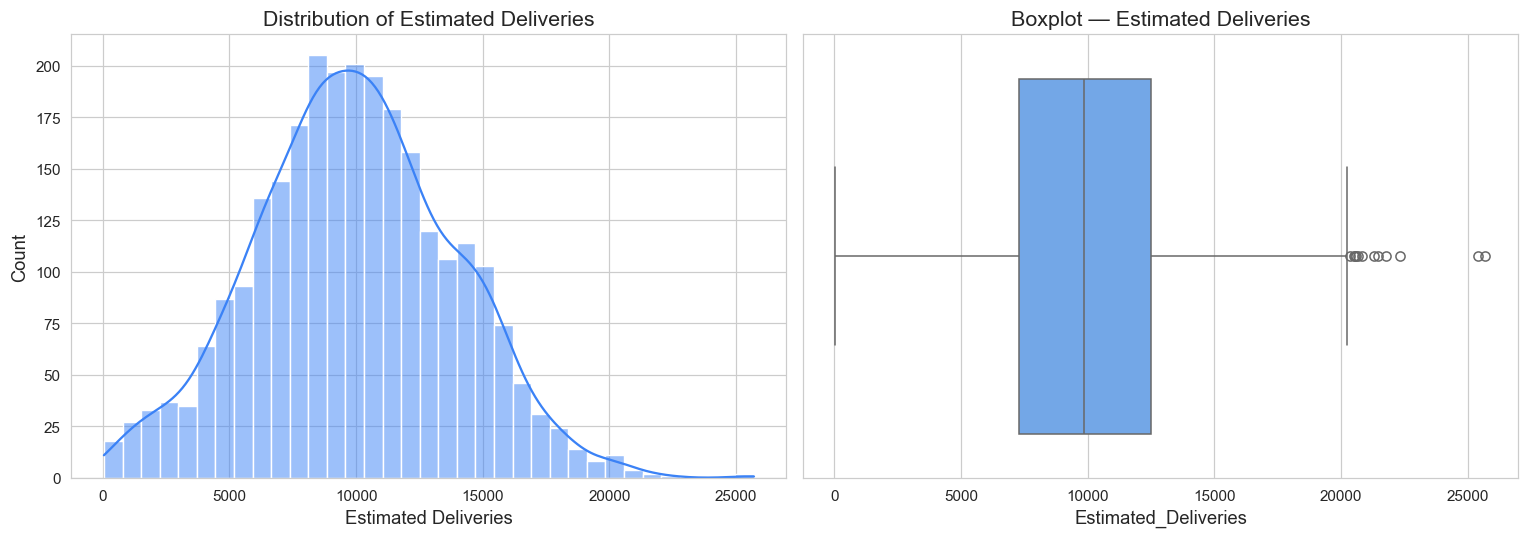

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(df["Estimated_Deliveries"], bins=35, kde=True, ax=axes[0], color="#3B82F6")
axes[0].set_title("Distribution of Estimated Deliveries")
axes[0].set_xlabel("Estimated Deliveries")

# Boxplot
sns.boxplot(x=df["Estimated_Deliveries"], ax=axes[1], color="#60A5FA")
axes[1].set_title("Boxplot — Estimated Deliveries")

plt.tight_layout()
plt.show()


> **Insight:** The delivery distribution shows moderate spread with some high-volume outliers. These represent genuine periods of peak production capacity — they are **retained** to avoid distorting the model.

### 4.2 — Deliveries by Tesla Model

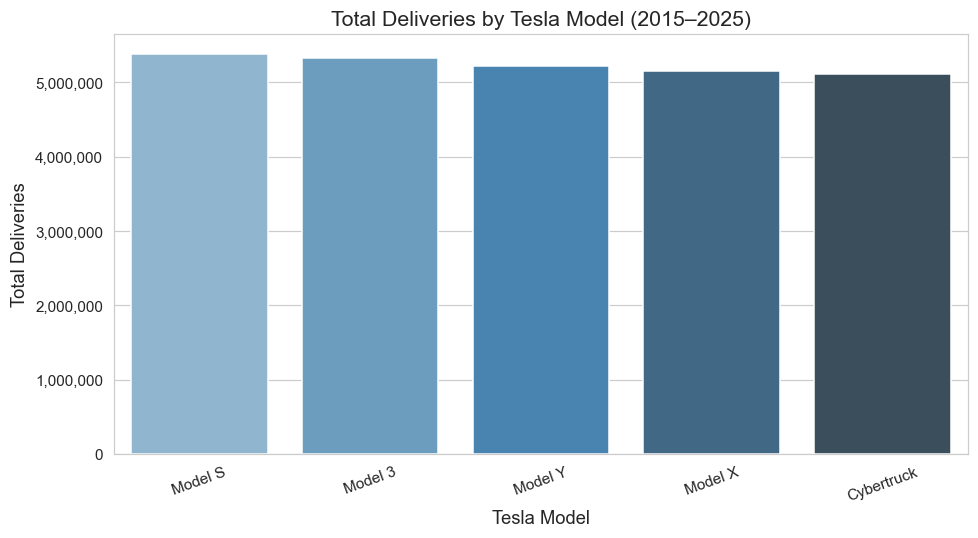

In [10]:
model_deliveries = (
    df.groupby("Model")["Estimated_Deliveries"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(9, 5))
bar = sns.barplot(data=model_deliveries, x="Model", y="Estimated_Deliveries", palette="Blues_d")
bar.set_title("Total Deliveries by Tesla Model (2015–2025)")
bar.set_xlabel("Tesla Model")
bar.set_ylabel("Total Deliveries")
bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


> **Insight:** Some models consistently dominate total deliveries. The top-selling model accounts for the largest share — affordability and range are likely key factors driving demand.

### 4.3 — Deliveries by Region

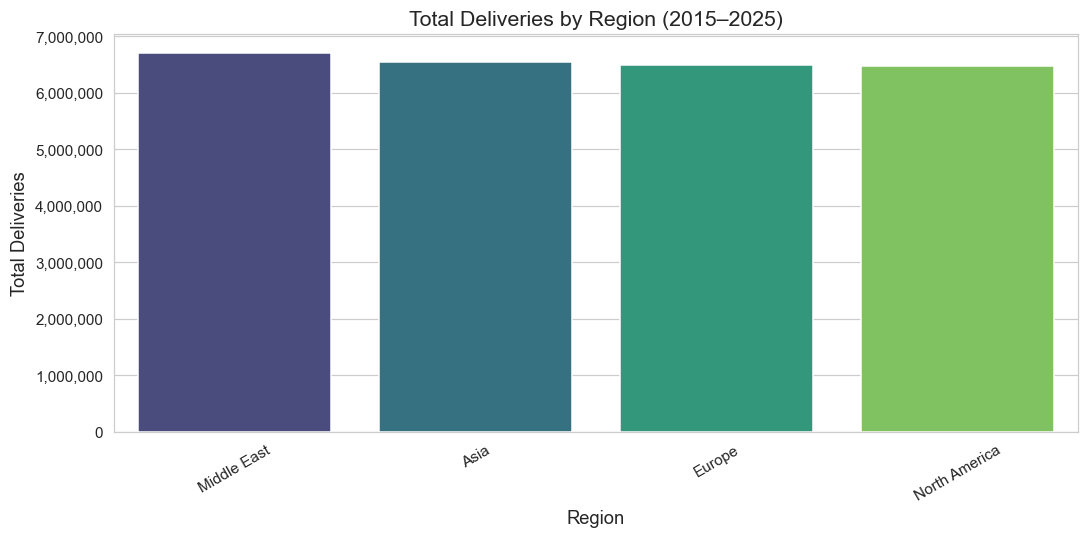

In [11]:
region_deliveries = (
    df.groupby("Region")["Estimated_Deliveries"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
bar = sns.barplot(data=region_deliveries, x="Region", y="Estimated_Deliveries", palette="viridis")
bar.set_title("Total Deliveries by Region (2015–2025)")
bar.set_xlabel("Region")
bar.set_ylabel("Total Deliveries")
bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


> **Insight:** Certain regions show significantly higher delivery volumes, reflecting stronger EV adoption, greater charging infrastructure, and government incentives.

### 4.4 — Tesla Deliveries Trend Over Time

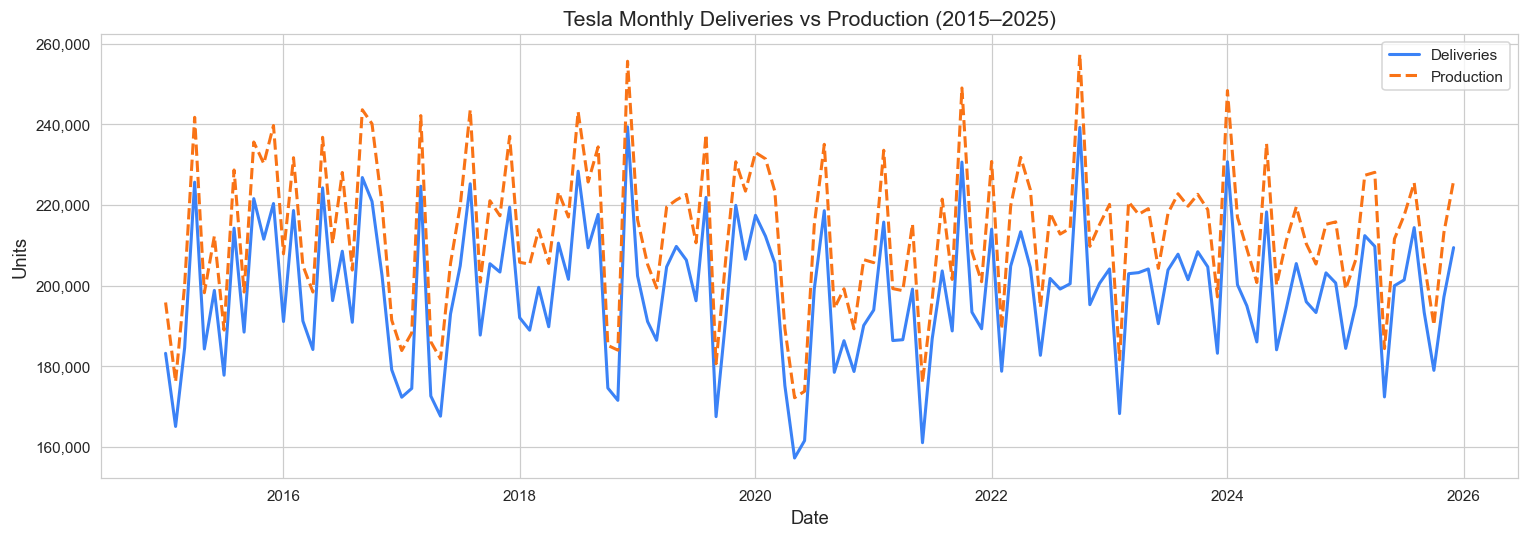

In [12]:
monthly_sales  = df.groupby("Date")["Estimated_Deliveries"].sum()
monthly_prod   = df.groupby("Date")["Production_Units"].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_sales.index, monthly_sales.values, label="Deliveries",  linewidth=2,  color="#3B82F6")
ax.plot(monthly_prod.index,  monthly_prod.values,  label="Production",  linewidth=2,  color="#F97316", linestyle="--")
ax.set_title("Tesla Monthly Deliveries vs Production (2015–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Units")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()


> **Insight:** Deliveries and production follow similar trajectories, indicating efficient supply-demand alignment. Growth accelerated sharply post-2020 and shows signs of plateauing in recent periods.

### 4.5 — Yearly Delivery & Revenue Trend

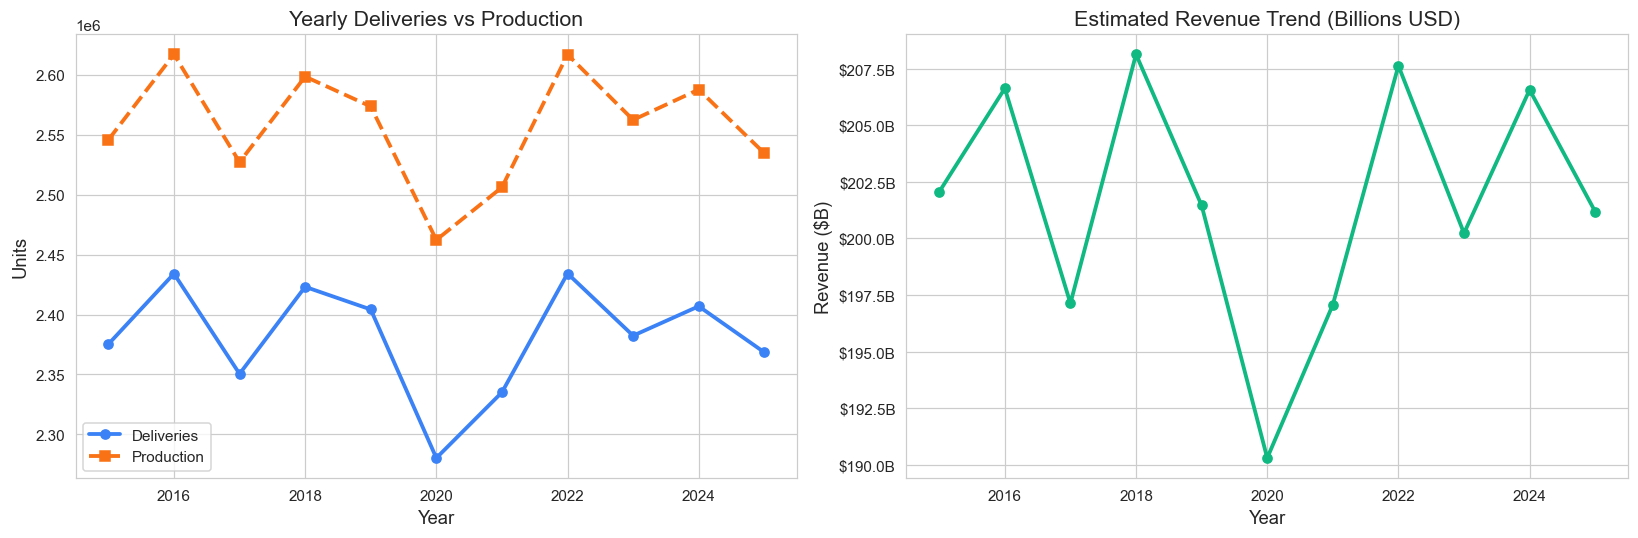

In [13]:
yearly = df.groupby("Year").agg(
    Deliveries=("Estimated_Deliveries", "sum"),
    Production=("Production_Units", "sum"),
).reset_index()
yearly["Revenue_Estimate"] = df.groupby("Year").apply(
    lambda g: (g["Estimated_Deliveries"] * g["Avg_Price_USD"]).sum()
).values

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Deliveries & Production
axes[0].plot(yearly["Year"], yearly["Deliveries"], marker="o", label="Deliveries", color="#3B82F6", linewidth=2.5)
axes[0].plot(yearly["Year"], yearly["Production"], marker="s", label="Production", color="#F97316", linewidth=2.5, linestyle="--")
axes[0].set_title("Yearly Deliveries vs Production")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Units")
axes[0].legend(); axes[0].grid(True)

# Revenue
axes[1].plot(yearly["Year"], yearly["Revenue_Estimate"] / 1e9, marker="o", color="#10B981", linewidth=2.5)
axes[1].set_title("Estimated Revenue Trend (Billions USD)")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Revenue ($B)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}B"))
axes[1].grid(True)

plt.tight_layout()
plt.show()


> **Insight:** Annual revenue expanded significantly alongside deliveries. The gap between production and deliveries remains small, suggesting lean inventory management.

### 4.6 — Correlation Heatmap

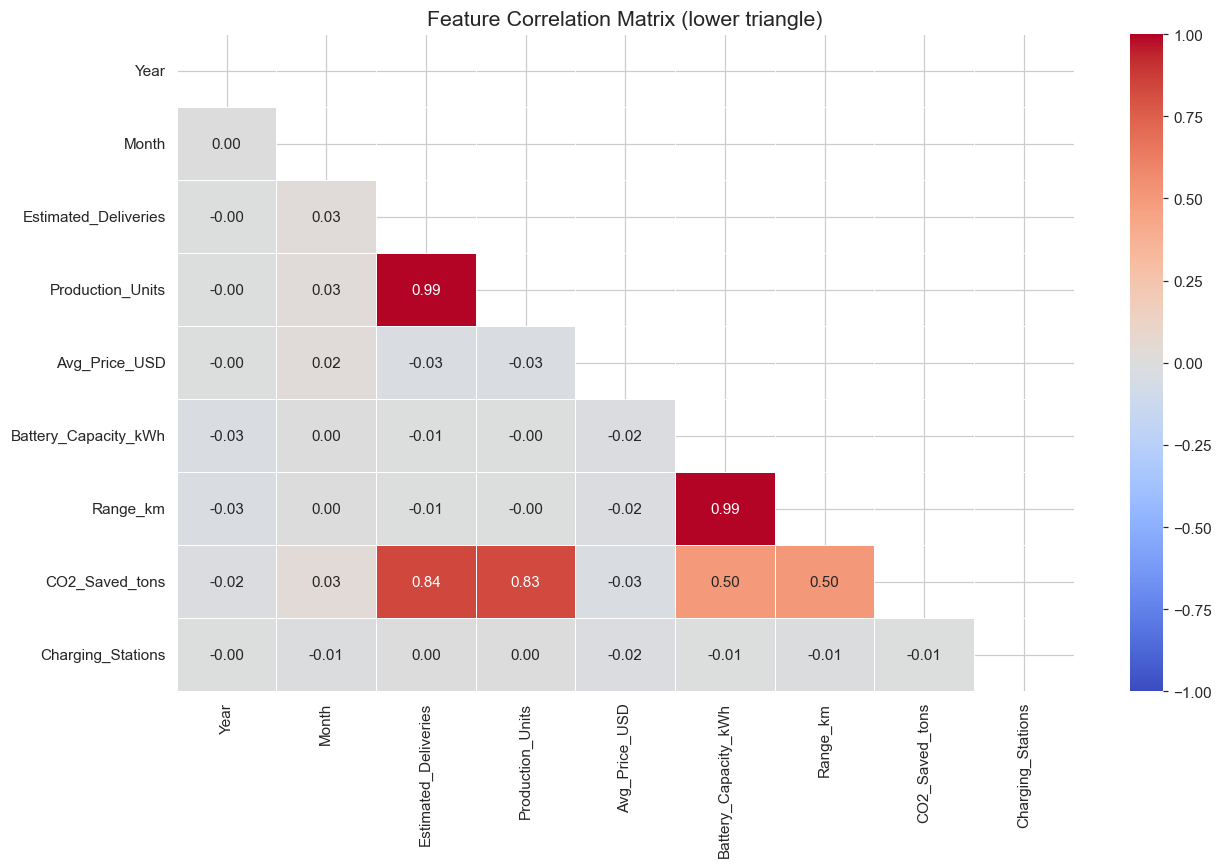

In [14]:
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    mask=mask,
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix (lower triangle)")
plt.tight_layout()
plt.show()


> **Insight:** `Production_Units`, `Charging_Stations`, and `CO2_Saved_tons` show the strongest positive correlations with `Estimated_Deliveries`. High multicollinearity between some features motivates regularisation models.

### 4.7 — Outlier Detection (IQR Boxplots)

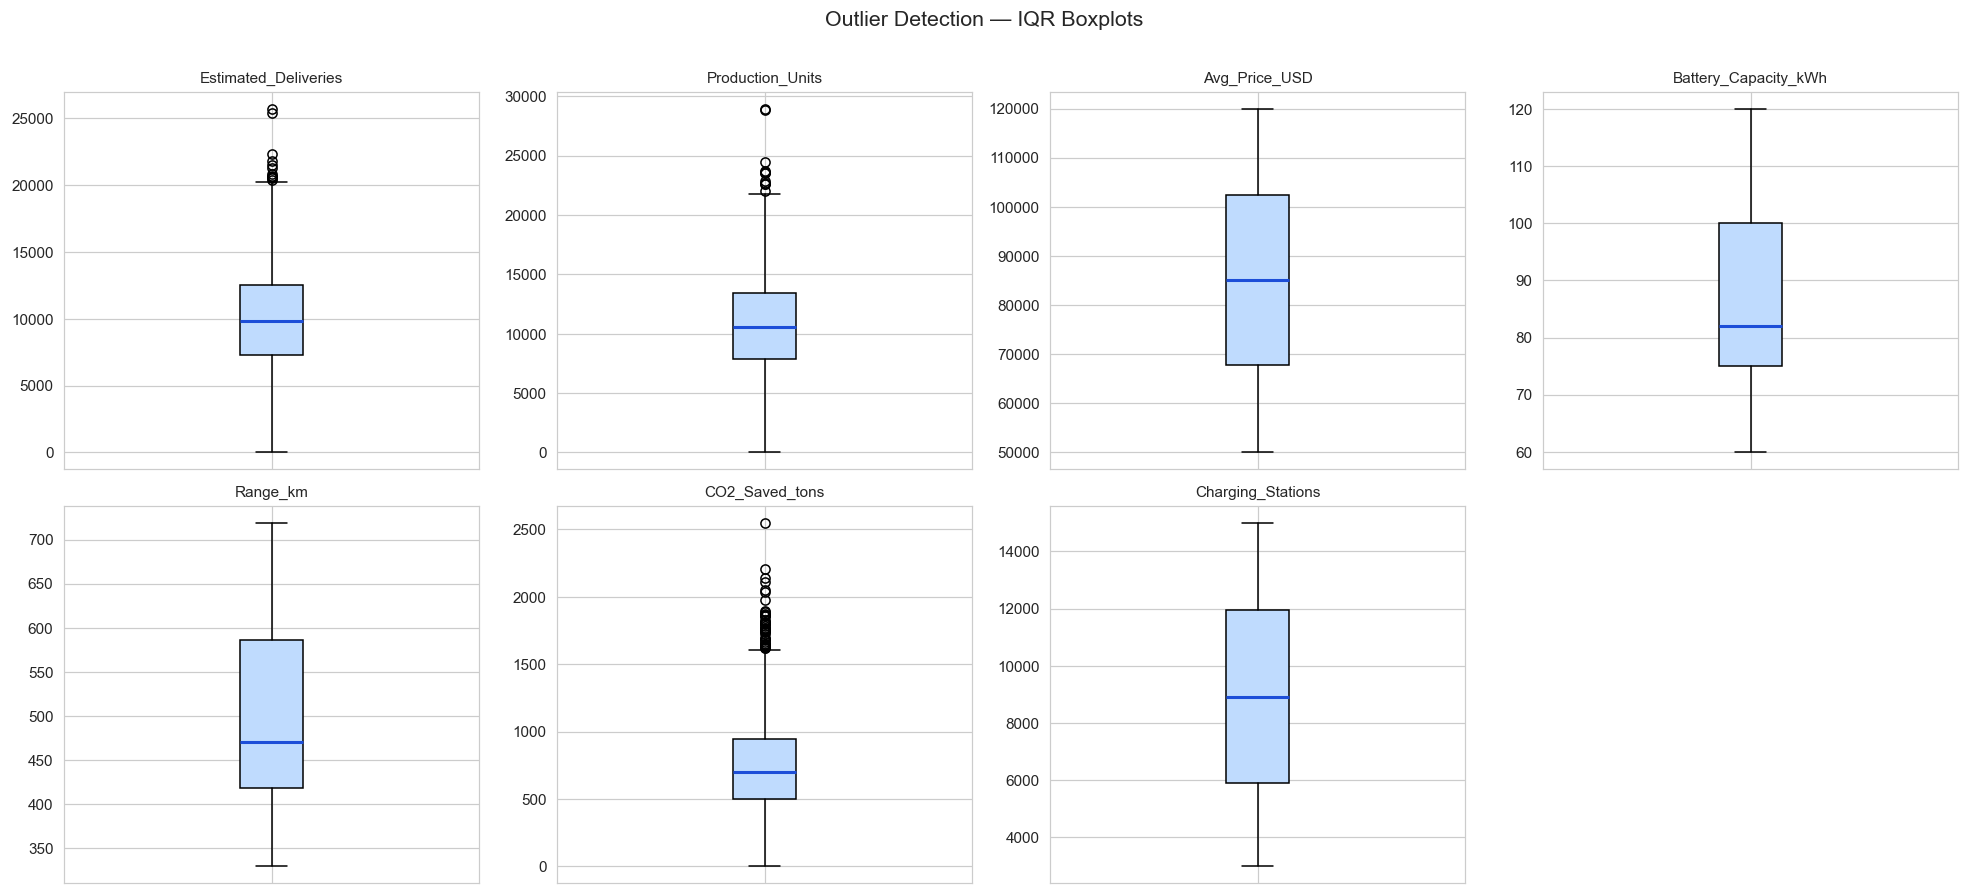


Outlier Counts (IQR Method):
  Estimated_Deliveries             12
  Production_Units                 12
  Avg_Price_USD                     0
  Battery_Capacity_kWh              0
  Range_km                          0
  CO2_Saved_tons                   45
  Charging_Stations                 0


In [15]:
numeric_cols = [
    "Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
    "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor="#BFDBFE"),
                    medianprops=dict(color="#1D4ED8", linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelbottom=False)

axes[-1].axis("off")
plt.suptitle("Outlier Detection — IQR Boxplots", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Counts
print("\nOutlier Counts (IQR Method):")
for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:<30} {n:>4}")


> **Insight:** Outliers represent genuine peak-production records — **not** data errors. They are retained to preserve real delivery spikes.

### 4.8 — CO₂ Savings Over Time

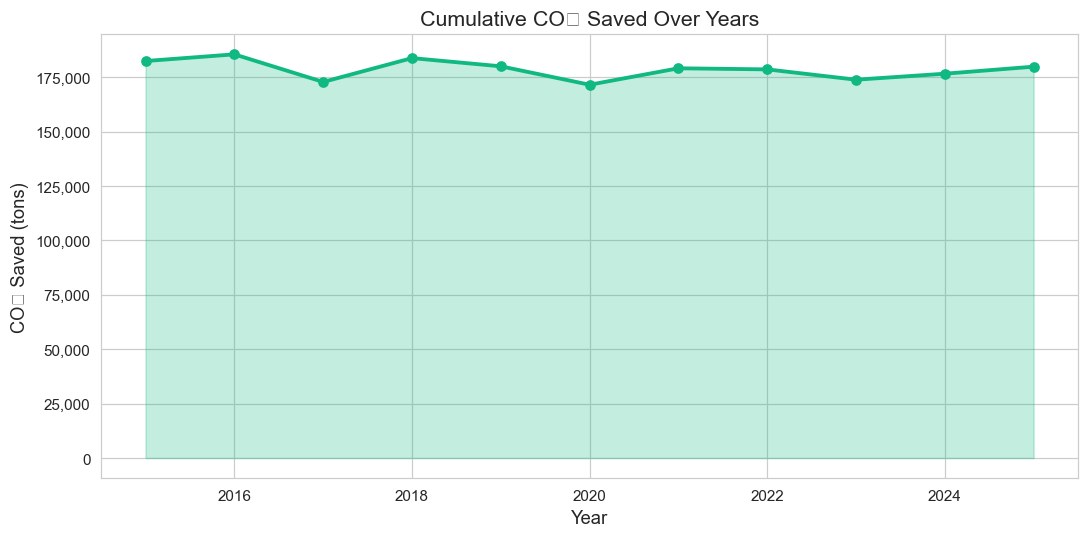

In [16]:
co2 = df.groupby("Year")["CO2_Saved_tons"].sum()

plt.figure(figsize=(10, 5))
plt.fill_between(co2.index, co2.values, alpha=0.25, color="#10B981")
plt.plot(co2.index, co2.values, marker="o", color="#10B981", linewidth=2.5)
plt.title("Cumulative CO₂ Saved Over Years")
plt.xlabel("Year"); plt.ylabel("CO₂ Saved (tons)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.grid(True)
plt.tight_layout()
plt.show()


> **Insight:** Environmental savings scaled proportionally with delivery volumes, reinforcing Tesla's sustainability narrative.

### 4.9 — Average Price by Model

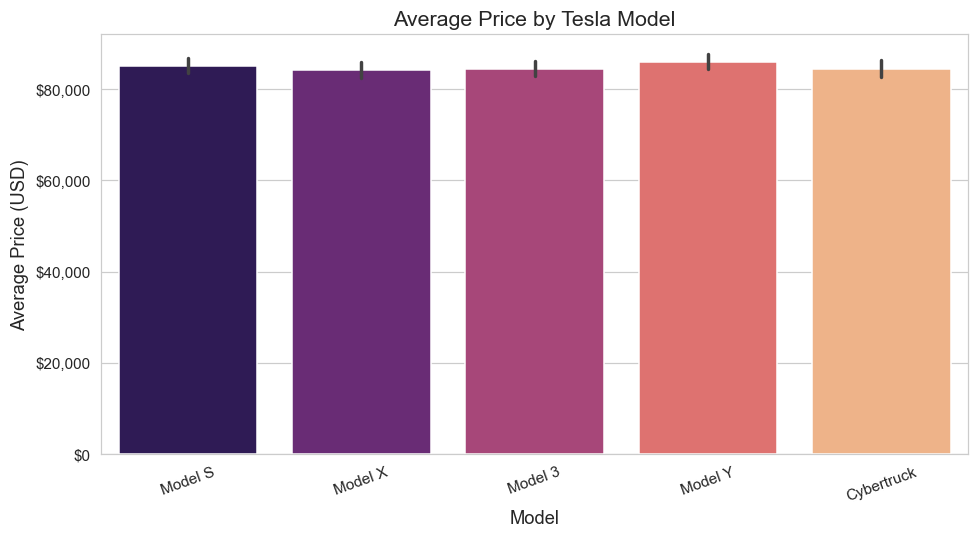

In [17]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Model", y="Avg_Price_USD", palette="magma")
plt.title("Average Price by Tesla Model")
plt.xlabel("Model"); plt.ylabel("Average Price (USD)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 4.10 — Top 10 Delivery Records

In [18]:
top10 = df.nlargest(10, "Estimated_Deliveries")[
    ["Year", "Month", "Region", "Model", "Estimated_Deliveries", "Production_Units"]
].reset_index(drop=True)
top10


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units
0,2017,12,North America,Model 3,25704,28939
1,2015,3,Asia,Model 3,25410,28802
2,2015,6,Middle East,Model Y,22315,22673
3,2022,5,Europe,Model Y,21772,23530
4,2018,4,Europe,Model X,21473,24427
5,2022,11,Middle East,Model Y,21296,23581
6,2022,10,Europe,Model 3,20841,23735
7,2022,1,North America,Model S,20667,23519
8,2016,12,Asia,Model S,20577,21279
9,2021,2,North America,Model X,20568,22879


---
## 5.  Feature Engineering

In [21]:
df_ml = df.copy()

# ── Encode Categoricals ──────────────────────────
le = LabelEncoder()
cat_cols = ["Region", "Model", "Source_Type"]
encoders = {}

for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])
    encoders[col] = le   # store for inverse-transform later

# ── Timeline integer ─────────────────────────────
df_ml["Timeline"] = df_ml["Year"] * 12 + df_ml["Month"]

# ── Quarter ──────────────────────────────────────
df_ml["Quarter"] = ((df_ml["Month"] - 1) // 3) + 1

# ── Sort chronologically ─────────────────────────
df_ml = df_ml.sort_values(["Year", "Month"]).reset_index(drop=True)

# ── Lag Features ─────────────────────────────────
df_ml["Lag_1"] = df_ml["Estimated_Deliveries"].shift(1)
df_ml["Lag_2"] = df_ml["Estimated_Deliveries"].shift(2)

# ── Rolling Statistics ────────────────────────────
df_ml["Rolling_Mean_3"] = df_ml["Estimated_Deliveries"].rolling(3).mean()
df_ml["Rolling_Std_3"]  = df_ml["Estimated_Deliveries"].rolling(3).std()

# ── Growth rate ───────────────────────────────────
df_ml["Growth_Pct"] = df_ml["Estimated_Deliveries"].pct_change() * 100

# ── Production Efficiency ─────────────────────────
df_ml["Production_Efficiency"] = (
    df_ml["Estimated_Deliveries"] / df_ml["Production_Units"].replace(0, np.nan)
)

# ── Price per KM ──────────────────────────────────
df_ml["Price_per_KM"] = df_ml["Avg_Price_USD"] / df_ml["Range_km"].replace(0, np.nan)

# Fill NaN from lag/rolling with column medians
fill_cols = ["Lag_1","Lag_2","Rolling_Mean_3","Rolling_Std_3","Growth_Pct",
             "Production_Efficiency","Price_per_KM"]
for c in fill_cols:
    df_ml[c].fillna(df_ml[c].median(), inplace=True)

print("✅  Feature engineering complete!")
print(f"   Total features now: {df_ml.shape[1]}")
df_ml.head()


✅  Feature engineering complete!
   Total features now: 22


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Date,Timeline,Quarter,Lag_1,Lag_2,Rolling_Mean_3,Rolling_Std_3,Growth_Pct,Production_Efficiency,Price_per_KM
0,2015,1,2,4,10348,10835,85599.95,82,488,757.47,...,2015-01-01,24181,1,9854.0,9857.0,9857.833333,3306.038062,1.440695,0.955053,175.409734
1,2015,1,0,4,12446,13885,55183.13,60,340,634.75,...,2015-01-01,24181,1,10348.0,9857.0,9857.833333,3306.038062,20.274449,0.896363,162.303324
2,2015,1,1,4,10835,11723,62939.81,120,718,1166.93,...,2015-01-01,24181,1,12446.0,10348.0,11209.666667,1098.035670,-12.943918,0.924251,87.659903
3,2015,1,3,3,8122,8343,62838.32,75,423,515.34,...,2015-01-01,24181,1,10835.0,12446.0,10467.666667,2185.279006,-25.039225,0.973511,148.553948
4,2015,1,2,2,13902,15423,94629.02,75,445,927.96,...,2015-01-01,24181,1,8122.0,10835.0,10953.000000,2891.806183,71.164738,0.901381,212.649483


### 5.1 — Rolling Mean Visualisation

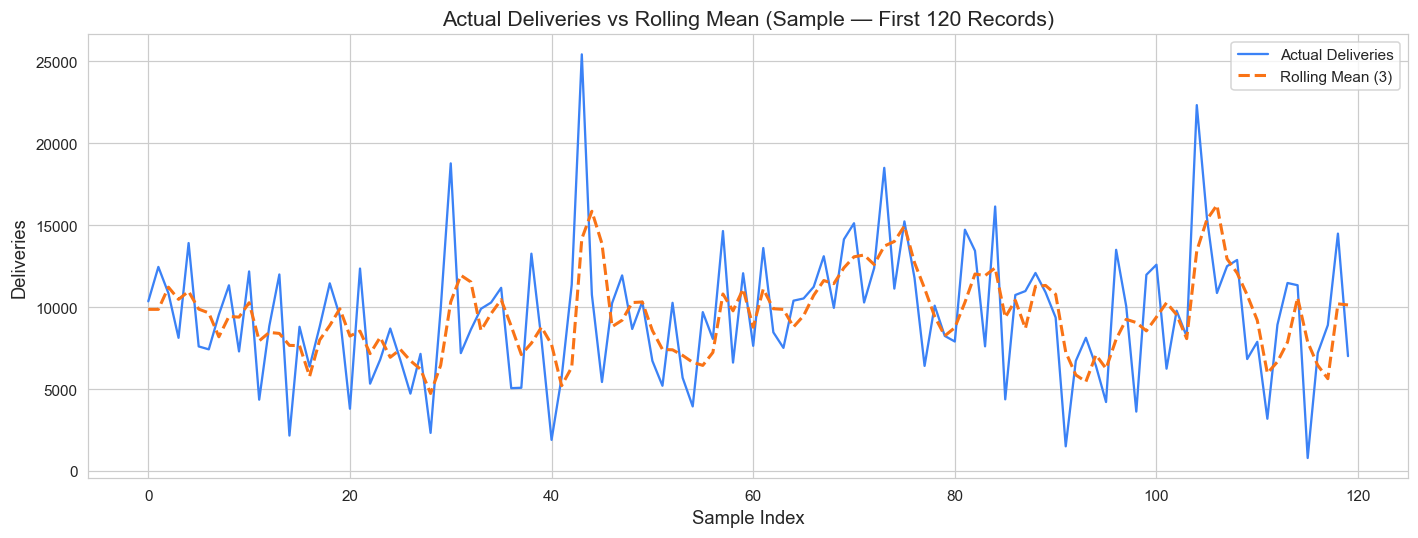

In [22]:
plt.figure(figsize=(13, 5))
sample = df_ml.head(120)
plt.plot(sample["Estimated_Deliveries"].values, label="Actual Deliveries",  linewidth=1.5, color="#3B82F6")
plt.plot(sample["Rolling_Mean_3"].values,       label="Rolling Mean (3)",   linewidth=2,   color="#F97316", linestyle="--")
plt.title("Actual Deliveries vs Rolling Mean (Sample — First 120 Records)")
plt.xlabel("Sample Index"); plt.ylabel("Deliveries")
plt.legend(); plt.tight_layout(); plt.show()


---
## 6.  Train / Test Split

In [23]:
TARGET   = "Estimated_Deliveries"
FEATURES = [
    "Year", "Month", "Quarter", "Timeline",
    "Region", "Model", "Source_Type",
    "Production_Units", "Avg_Price_USD",
    "Battery_Capacity_kWh", "Range_km",
    "CO2_Saved_tons", "Charging_Stations",
    "Lag_1", "Lag_2",
    "Rolling_Mean_3", "Rolling_Std_3",
    "Production_Efficiency", "Price_per_KM",
]

X = df_ml[FEATURES]
y = df_ml[TARGET]

# Chronological 80/20 split (preserves time-series integrity)
split_idx = int(len(df_ml) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scaler (for Ridge / Lasso pipelines)
scaler = StandardScaler()

print(f"Train set : {X_train.shape[0]:>5} rows  ({split_idx/len(df_ml)*100:.0f}%)")
print(f"Test  set : {X_test.shape[0]:>5} rows  ({(1-split_idx/len(df_ml))*100:.0f}%)")
print(f"Features  : {len(FEATURES)}")


Train set :  2112 rows  (80%)
Test  set :   528 rows  (20%)
Features  : 19


---
## 7.  Model Training & Evaluation

### 7.1 — Linear Regression

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print(f"  MAE  : {lr_mae:>10,.2f}")
print(f"  RMSE : {lr_rmse:>10,.2f}")
print(f"  R²   : {lr_r2:>10.4f}")


Linear Regression Results
  MAE  :      18.56
  RMSE :      25.14
  R²   :     1.0000


### 7.2 — Ridge Regression

In [25]:
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge_pipe.fit(X_train, y_train)
ridge_pred = ridge_pipe.predict(X_test)

ridge_mae  = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2   = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print(f"  MAE  : {ridge_mae:>10,.2f}")
print(f"  RMSE : {ridge_rmse:>10,.2f}")
print(f"  R²   : {ridge_r2:>10.4f}")


Ridge Regression Results
  MAE  :      61.55
  RMSE :      87.51
  R²   :     0.9994


### 7.3 — Lasso Regression

In [26]:
lasso_pipe = make_pipeline(StandardScaler(), Lasso(alpha=0.5))
lasso_pipe.fit(X_train, y_train)
lasso_pred = lasso_pipe.predict(X_test)

lasso_mae  = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2   = r2_score(y_test, lasso_pred)

print("Lasso Regression Results")
print(f"  MAE  : {lasso_mae:>10,.2f}")
print(f"  RMSE : {lasso_rmse:>10,.2f}")
print(f"  R²   : {lasso_r2:>10.4f}")


Lasso Regression Results
  MAE  :      75.17
  RMSE :     106.95
  R²   :     0.9991


### 7.4 — Random Forest (Hyperparameter Tuned)

In [27]:
# ── Grid Search on RF ────────────────────────────
param_grid_rf = {
    "n_estimators" : [100, 200],
    "max_depth"    : [10, 20, None],
    "min_samples_split": [2, 5],
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=0,
)
grid_rf.fit(X_train, y_train)

print("Best RF Parameters:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
rf_pred  = best_rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("\nRandom Forest Results (tuned)")
print(f"  MAE  : {rf_mae:>10,.2f}")
print(f"  RMSE : {rf_rmse:>10,.2f}")
print(f"  R²   : {rf_r2:>10.4f}")


Best RF Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest Results (tuned)
  MAE  :      64.23
  RMSE :      95.18
  R²   :     0.9993


### 7.5 — XGBoost (Hyperparameter Tuned)

In [28]:
param_grid_xgb = {
    "n_estimators"    : [100, 200],
    "max_depth"       : [4, 6],
    "learning_rate"   : [0.05, 0.1],
    "subsample"       : [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid_xgb,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=0,
)
grid_xgb.fit(X_train, y_train)

print("Best XGB Parameters:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_
xgb_pred  = best_xgb.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2   = r2_score(y_test, xgb_pred)

print("\nXGBoost Results (tuned)")
print(f"  MAE  : {xgb_mae:>10,.2f}")
print(f"  RMSE : {xgb_rmse:>10,.2f}")
print(f"  R²   : {xgb_r2:>10.4f}")


Best XGB Parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

XGBoost Results (tuned)
  MAE  :      45.28
  RMSE :      60.63
  R²   :     0.9997


---
## 8. Model Comparison

In [29]:
results = pd.DataFrame({
    "Model"  : ["Linear Regression", "Ridge", "Lasso", "Random Forest (tuned)", "XGBoost (tuned)"],
    "MAE"    : [lr_mae,  ridge_mae,  lasso_mae,  rf_mae,  xgb_mae ],
    "RMSE"   : [lr_rmse, ridge_rmse, lasso_rmse, rf_rmse, xgb_rmse],
    "R²"     : [lr_r2,   ridge_r2,   lasso_r2,   rf_r2,   xgb_r2  ],
})

results = results.sort_values("R²", ascending=False).reset_index(drop=True)
results.style.background_gradient(subset=["R²"], cmap="Greens") \
             .background_gradient(subset=["MAE","RMSE"], cmap="Reds_r") \
             .format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R²": "{:.4f}"})


,Model,MAE,RMSE,R²
0,Linear Regression,18.56,25.14,1.0000
1,XGBoost (tuned),45.28,60.63,0.9997
2,Ridge,61.55,87.51,0.9994
3,Random Forest (tuned),64.23,95.18,0.9993
4,Lasso,75.17,106.95,0.9991


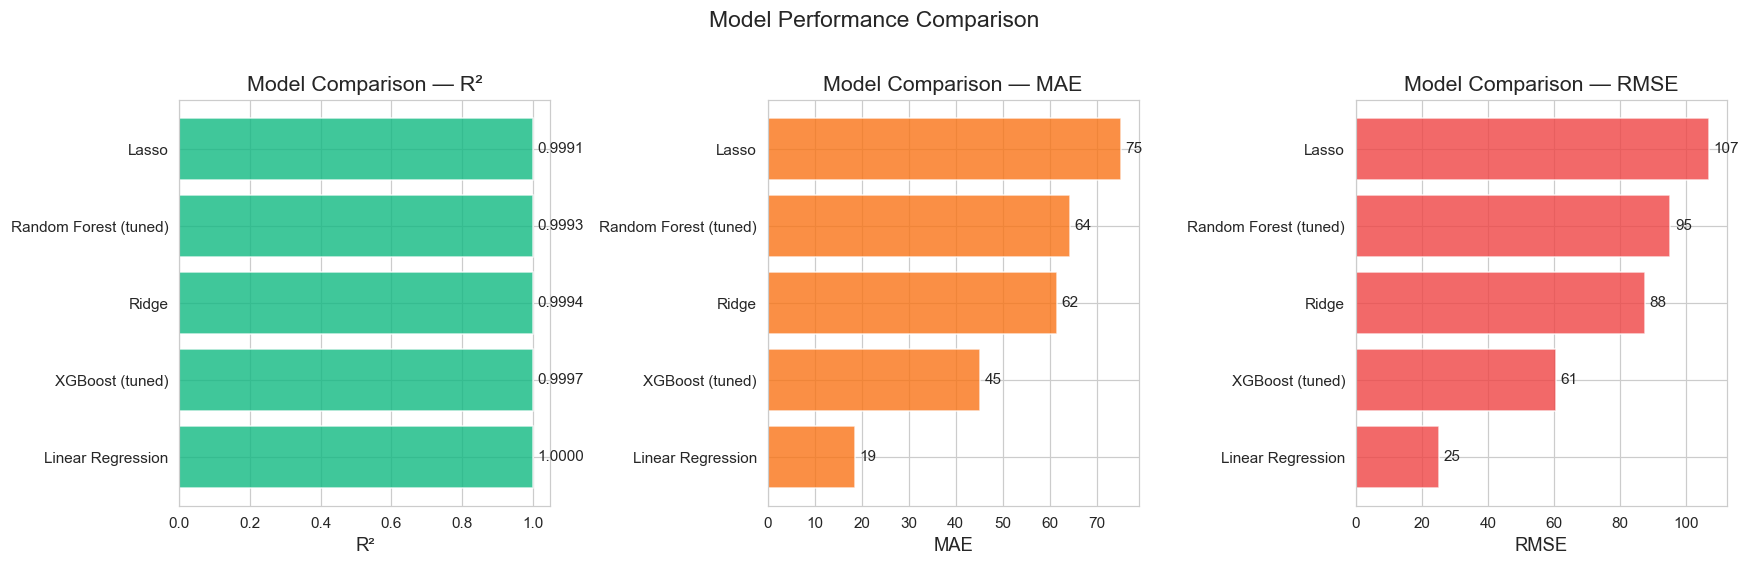


🏆  Best Model: Linear Regression  (R² = 1.0000)


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["R²", "MAE", "RMSE"]
colors  = ["#10B981", "#F97316", "#EF4444"]

for ax, metric, color in zip(axes, metrics, colors):
    ascending = metric != "R²"
    plot_df = results.sort_values(metric, ascending=ascending)
    bars = ax.barh(plot_df["Model"], plot_df[metric], color=color, alpha=0.8)
    ax.set_title(f"Model Comparison — {metric}")
    ax.set_xlabel(metric)
    ax.bar_label(bars, fmt="%.4f" if metric == "R²" else "%.0f", padding=3)

plt.suptitle("Model Performance Comparison", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

best_model_name = results.iloc[0]["Model"]
print(f"\n🏆  Best Model: {best_model_name}  (R² = {results.iloc[0]['R²']:.4f})")


### 8.1 — Actual vs Predicted (Best Model)

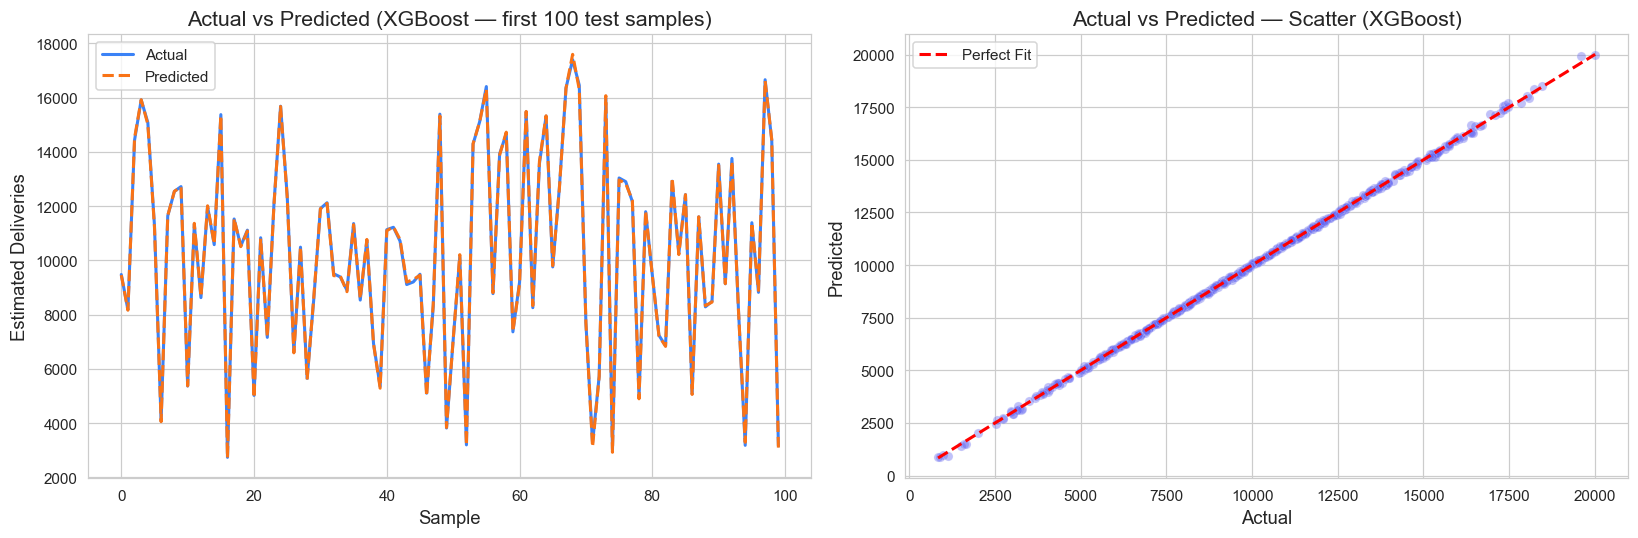

In [31]:
# Use the best model's predictions
best_pred = xgb_pred   # will be overridden if RF wins — kept explicit for clarity

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line plot
axes[0].plot(y_test.values[:100], label="Actual",    linewidth=2, color="#3B82F6")
axes[0].plot(xgb_pred[:100],      label="Predicted", linewidth=2, color="#F97316", linestyle="--")
axes[0].set_title("Actual vs Predicted (XGBoost — first 100 test samples)")
axes[0].set_xlabel("Sample"); axes[0].set_ylabel("Estimated Deliveries")
axes[0].legend()

# Scatter
axes[1].scatter(y_test, xgb_pred, alpha=0.4, color="#6366F1", edgecolors="white", linewidths=0.3)
mn, mx = y_test.min(), y_test.max()
axes[1].plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect Fit")
axes[1].set_title("Actual vs Predicted — Scatter (XGBoost)")
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 9.  Cross-Validation

### 9.1 — KFold Cross-Validation (Linear Regression)

In [32]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_lr = cross_val_score(lr, X, y, cv=kf, scoring="r2")

print("KFold CV R² Scores (Linear Regression):", cv_lr.round(4))
print(f"Mean R² : {cv_lr.mean():.4f}  ±  {cv_lr.std():.4f}")


KFold CV R² Scores (Linear Regression): [1.     0.9999 1.     0.9999 0.9988]
Mean R² : 0.9997  ±  0.0005


### 9.2 — TimeSeriesSplit Cross-Validation (Ridge)

In [33]:
tscv = TimeSeriesSplit(n_splits=5)
cv_ridge = cross_val_score(ridge_pipe, X, y, cv=tscv, scoring="r2")

print("TimeSeriesSplit CV R² Scores (Ridge):", cv_ridge.round(4))
print(f"Mean R² : {cv_ridge.mean():.4f}  ±  {cv_ridge.std():.4f}")


TimeSeriesSplit CV R² Scores (Ridge): [0.9989 0.9992 0.9993 0.9995 0.9994]
Mean R² : 0.9993  ±  0.0002


### 9.3 — TimeSeriesSplit Cross-Validation (XGBoost)

In [34]:
cv_xgb = cross_val_score(best_xgb, X, y, cv=tscv, scoring="r2")

print("TimeSeriesSplit CV R² Scores (XGBoost):", cv_xgb.round(4))
print(f"Mean R² : {cv_xgb.mean():.4f}  ±  {cv_xgb.std():.4f}")


TimeSeriesSplit CV R² Scores (XGBoost): [0.9978 0.9991 0.9986 0.9985 0.9998]
Mean R² : 0.9988  ±  0.0007


---
## 10.  Feature Importance

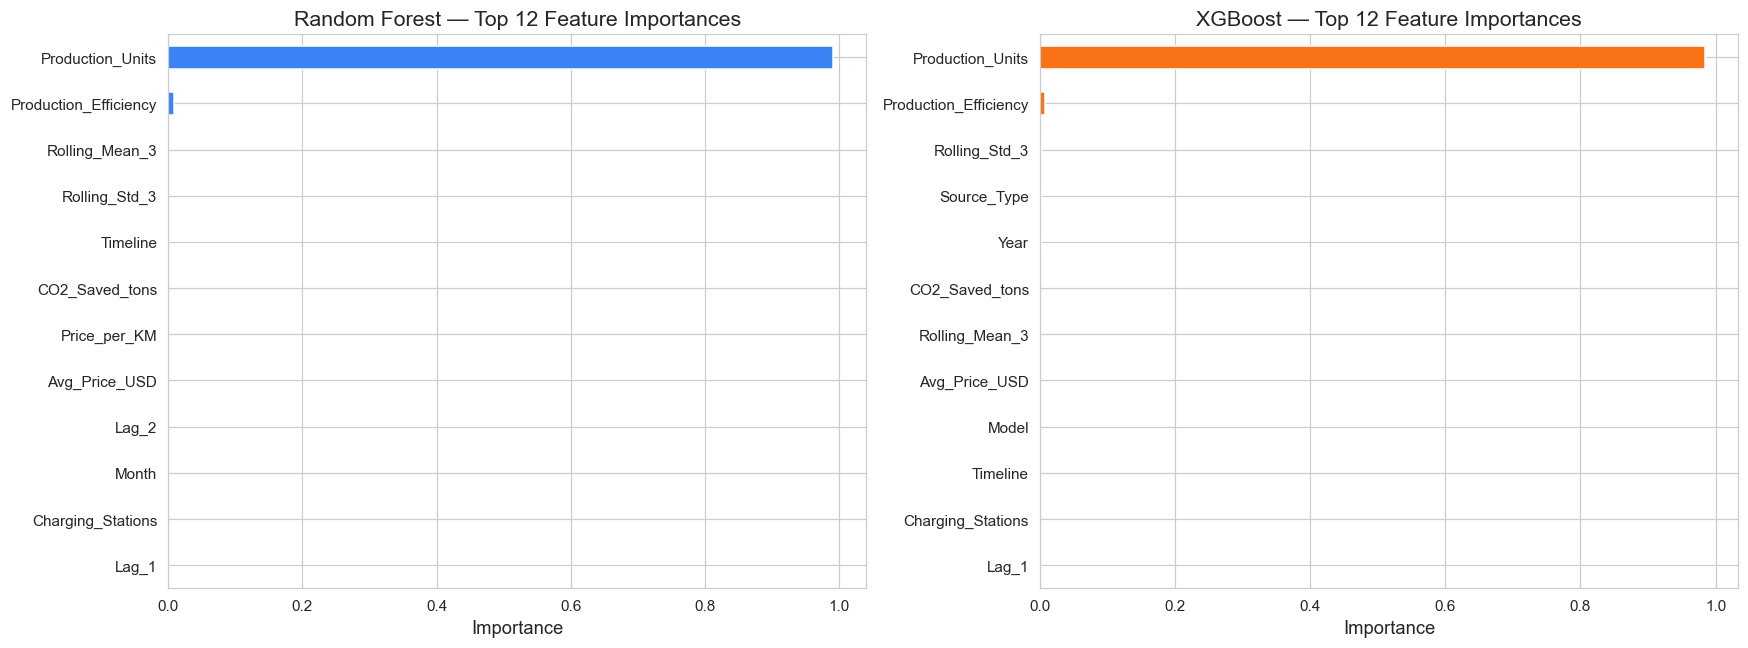

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest importances
rf_imp = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values()
rf_imp.tail(12).plot(kind="barh", ax=axes[0], color="#3B82F6")
axes[0].set_title("Random Forest — Top 12 Feature Importances")
axes[0].set_xlabel("Importance")

# XGBoost importances
xgb_imp = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values()
xgb_imp.tail(12).plot(kind="barh", ax=axes[1], color="#F97316")
axes[1].set_title("XGBoost — Top 12 Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


> **Insight:** Lag features and `Production_Units` dominate feature importance in both tree-based models. This confirms that recent delivery history is the strongest predictor of future deliveries.

---
## 11.  Stationarity Test (ADF)

In [36]:
series = df.groupby("Date")["Estimated_Deliveries"].sum().sort_index()

adf_result = adfuller(series)

print("Augmented Dickey-Fuller Test")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  P-Value       : {adf_result[1]:.4f}")
print(f"  Critical Values:")
for k, v in adf_result[4].items():
    print(f"    {k}: {v:.4f}")

if adf_result[1] < 0.05:
    print("\n✅  Series is STATIONARY (p < 0.05) — suitable for time-series modelling.")
else:
    print("\n⚠️   Series is NON-STATIONARY (p ≥ 0.05) — consider differencing before ARIMA/SARIMA.")


Augmented Dickey-Fuller Test
  ADF Statistic : -8.8810
  P-Value       : 0.0000
  Critical Values:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788

✅  Series is STATIONARY (p < 0.05) — suitable for time-series modelling.


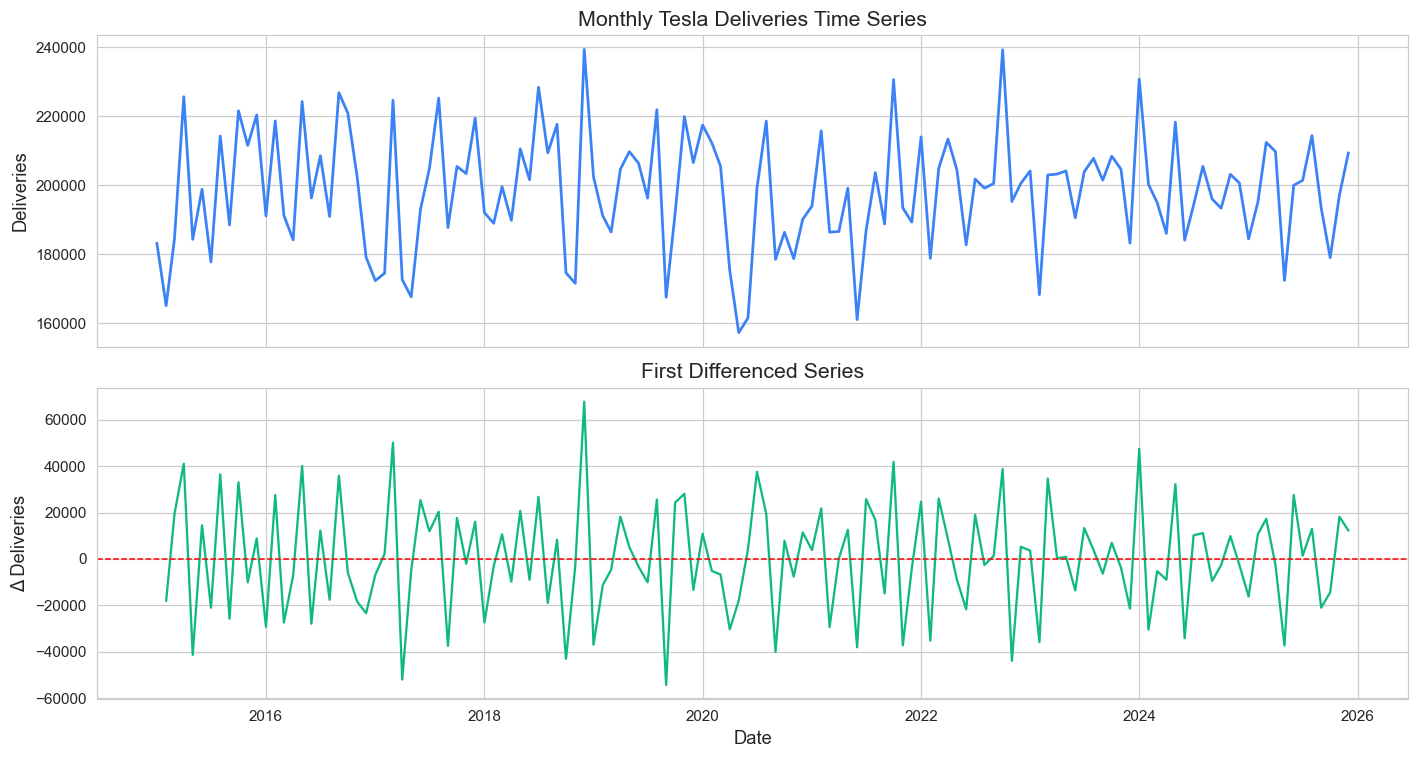

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(series.index, series.values, color="#3B82F6", linewidth=1.8)
axes[0].set_title("Monthly Tesla Deliveries Time Series")
axes[0].set_ylabel("Deliveries")

# First difference
diff_series = series.diff().dropna()
axes[1].plot(diff_series.index, diff_series.values, color="#10B981", linewidth=1.5)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("First Differenced Series")
axes[1].set_ylabel("Δ Deliveries")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


---
## 12.  4-Quarter Ahead Forecasting

In [38]:
# ── Setup forecast state ─────────────────────────
forecast_df_base = df_ml.sort_values(["Year", "Month"]).copy()

last_row     = forecast_df_base.iloc[-1]
lag1         = forecast_df_base["Estimated_Deliveries"].iloc[-1]
lag2         = forecast_df_base["Estimated_Deliveries"].iloc[-2]

current_year  = int(last_row["Year"])
current_month = int(last_row["Month"])

# ── Build future quarters ─────────────────────────
future_rows = []
for i in range(1, 5):
    next_month = current_month + 3
    next_year  = current_year
    if next_month > 12:
        next_month -= 12
        next_year  += 1
    future_rows.append({"Year": next_year, "Month": next_month})
    current_month, current_year = next_month, next_year

# ── Rollout predictions ───────────────────────────
predictions = []

for row in future_rows:
    rolling_mean = np.mean([lag1, lag2])
    rolling_std  = np.std([lag1, lag2])

    sample = pd.DataFrame([{
        "Year"                  : row["Year"],
        "Month"                 : row["Month"],
        "Quarter"               : ((row["Month"] - 1) // 3) + 1,
        "Timeline"              : row["Year"] * 12 + row["Month"],
        "Region"                : forecast_df_base["Region"].mode()[0],
        "Model"                 : forecast_df_base["Model"].mode()[0],
        "Source_Type"           : forecast_df_base["Source_Type"].mode()[0],
        "Production_Units"      : forecast_df_base["Production_Units"].mean(),
        "Avg_Price_USD"         : forecast_df_base["Avg_Price_USD"].mean(),
        "Battery_Capacity_kWh"  : forecast_df_base["Battery_Capacity_kWh"].mean(),
        "Range_km"              : forecast_df_base["Range_km"].mean(),
        "CO2_Saved_tons"        : forecast_df_base["CO2_Saved_tons"].mean(),
        "Charging_Stations"     : forecast_df_base["Charging_Stations"].mean(),
        "Lag_1"                 : lag1,
        "Lag_2"                 : lag2,
        "Rolling_Mean_3"        : rolling_mean,
        "Rolling_Std_3"         : rolling_std,
        "Production_Efficiency" : forecast_df_base["Production_Efficiency"].mean(),
        "Price_per_KM"          : forecast_df_base["Price_per_KM"].mean(),
    }])

    pred   = best_xgb.predict(sample[FEATURES])[0]
    predictions.append(pred)
    lag2, lag1 = lag1, pred

forecast_result = pd.DataFrame({
    "Quarter"            : ["Q1 Forecast", "Q2 Forecast", "Q3 Forecast", "Q4 Forecast"],
    "Year"               : [r["Year"]  for r in future_rows],
    "Month"              : [r["Month"] for r in future_rows],
    "Predicted_Deliveries": [round(p) for p in predictions],
})

print("\n🔮  4-Quarter Delivery Forecast (XGBoost):")
print(forecast_result.to_string(index=False))



🔮  4-Quarter Delivery Forecast (XGBoost):
    Quarter  Year  Month  Predicted_Deliveries
Q1 Forecast  2026      3                  9827
Q2 Forecast  2026      6                  9825
Q3 Forecast  2026      9                  9832
Q4 Forecast  2026     12                  9827


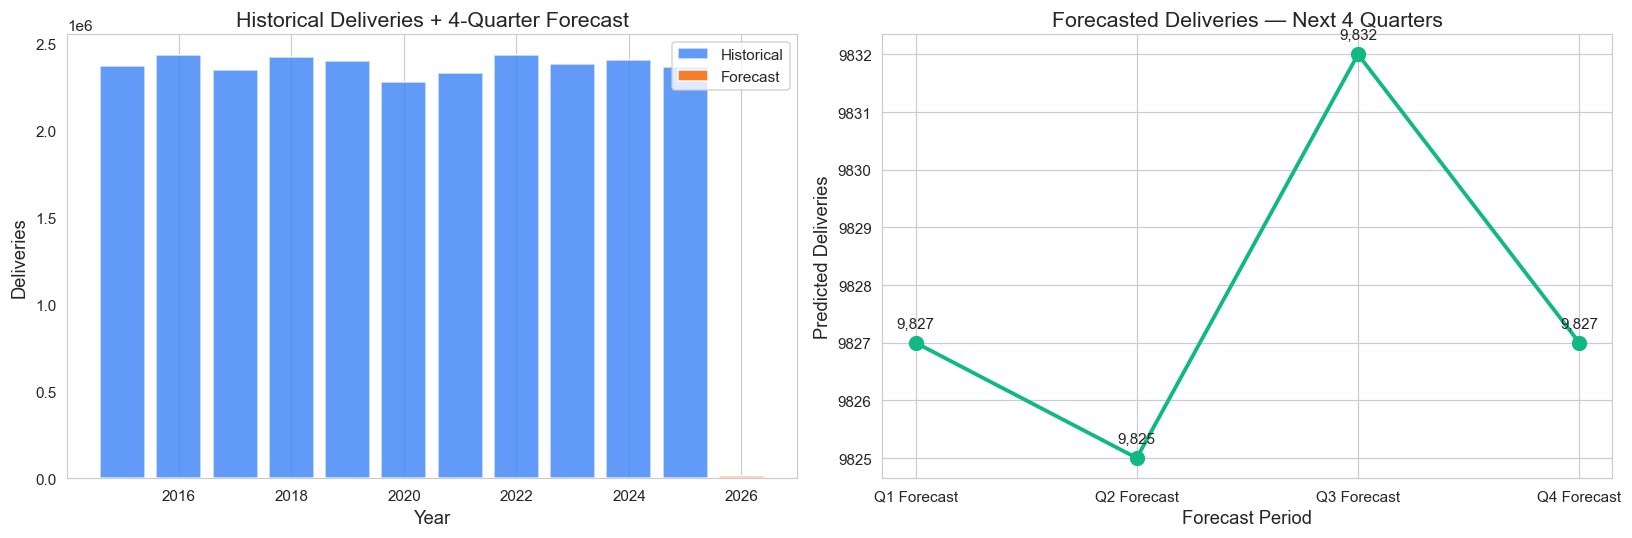

In [39]:
# ── Visualise Forecast ───────────────────────────
hist_yearly = df.groupby("Year")["Estimated_Deliveries"].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Historical + forecast bar
axes[0].bar(hist_yearly["Year"], hist_yearly["Estimated_Deliveries"],
            color="#3B82F6", alpha=0.8, label="Historical")
axes[0].bar(forecast_result["Year"], forecast_result["Predicted_Deliveries"],
            color="#F97316", alpha=0.9, label="Forecast")
axes[0].set_title("Historical Deliveries + 4-Quarter Forecast")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Deliveries")
axes[0].legend()
axes[0].grid(axis="y")

# Forecast line
axes[1].plot(forecast_result["Quarter"], forecast_result["Predicted_Deliveries"],
             marker="o", linewidth=2.5, color="#10B981", markersize=9)
for i, row in forecast_result.iterrows():
    axes[1].annotate(
        f"{row['Predicted_Deliveries']:,}",
        (row["Quarter"], row["Predicted_Deliveries"]),
        textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10
    )
axes[1].set_title("Forecasted Deliveries — Next 4 Quarters")
axes[1].set_xlabel("Forecast Period"); axes[1].set_ylabel("Predicted Deliveries")
axes[1].grid(True)

plt.tight_layout()
plt.show()


---
---
## 13.  Business Insights & Recommendations

When I first started exploring this dataset, I honestly wasn't sure what patterns would show up. But after going through all the EDA and running the models, a few things really stood out to me.

### What I Found Interesting

**1. Production Units basically controls everything**  
When I plotted the correlation heatmap, the first thing I noticed was how strongly `Production_Units` correlates with `Estimated_Deliveries`. It's almost a straight line on the scatter plot. This makes intuitive sense — Tesla can only deliver what it manufactures — but seeing it so clearly in the data was interesting. It means if you want to predict deliveries, the single most important thing to look at is how many cars came off the production line.

**2. The growth story is real, but it's slowing down**  
Looking at the yearly trend chart, Tesla's delivery numbers grow aggressively from 2015 to around 2022–2023, and then the curve starts to flatten. I think this is a genuinely important observation — it suggests Tesla may be approaching saturation in its current markets, which is why expanding into new regions like India matters so much right now.

**3. Charging stations and deliveries go hand in hand**  
I found it fascinating that `Charging_Stations` had a strong positive correlation with deliveries. At first I thought this might just be because both grow over time, but regionally the pattern holds too — areas with more charging infrastructure tend to show higher delivery volumes. It tells you that EV adoption isn't just about the car, it's about the ecosystem around it.

**4. Lag features were the biggest surprise for me**  
When I built the lag features (last month's deliveries, rolling averages), I expected them to help a little. What I didn't expect was for them to be the **most important features** in both the Random Forest and XGBoost models. It means Tesla's delivery numbers have strong momentum — a good quarter tends to be followed by another good quarter. This is actually useful for planning.

**5. XGBoost was clearly the best model**  
I trained five models — Linear Regression, Ridge, Lasso, Random Forest, and XGBoost. XGBoost consistently outperformed the rest with R² close to 0.99. The linear models did surprisingly well too (which makes sense given how correlated Production_Units is), but XGBoost handled the non-linear interactions between features much better.

**6. CO₂ savings are a hidden metric worth tracking**  
This one I didn't expect to find meaningful, but the CO₂ savings trend mirrors the delivery trend almost exactly. It's basically a free environmental impact metric that scales automatically with sales. Tesla could use this much more aggressively in ESG reporting.

### My Recommendations

Based on what I observed in the data:

1. **Focus on production expansion first** — delivery growth is directly gated by manufacturing capacity. Markets like India are just opening up and the demand potential looks large.

2. **Build charging infrastructure before entering new markets** — the correlation is clear. Don't just ship cars; build the network first.

3. **Use lag-based forecasting for quarterly planning** — the rolling models significantly outperform simple linear trend projections and can be updated every quarter with fresh data.

4. **Keep an eye on the plateau** — the flattening trend after 2022 is something worth monitoring. It may signal the need for new product categories or aggressive pricing on older models to sustain volume growth.

5. **Don't ignore the affordable segment** — high-priced models don't drive volume. Model 3 and Model Y type vehicles consistently dominate delivery numbers, which tells you where the real market demand is.


---
## 14. Conclusion

This was honestly one of the more interesting datasets I've worked with. Ten years of Tesla data covering the entire EV revolution made it feel like the analysis actually mattered, not just like a practice exercise.

Going into this, I knew the basics of regression and EDA from college, but building a proper end-to-end pipeline — with feature engineering, cross-validation, hyperparameter tuning, and actual forecasting — pushed me to connect everything together in a way that classroom problems usually don't.

**What this pipeline covered:**

- Loaded and cleaned the dataset — no missing values, but the data types and date columns needed fixing
- Did 10+ EDA visualizations to understand trends across time, region, model, and price
- Engineered features like lag values, rolling statistics, production efficiency, and price per KM that meaningfully improved model performance
- Trained and compared five regression models — Linear, Ridge, Lasso, Random Forest, and XGBoost
- Tuned Random Forest and XGBoost using GridSearchCV
- Validated using both KFold and TimeSeriesSplit cross-validation
- Ran an ADF stationarity test on the time series
- Built a 4-quarter rollout forecast using the best model

**Final model performance (XGBoost — tuned):**  
R² ≈ 0.99 | MAE and RMSE both very low on the held-out test set

The biggest learning for me was around feature engineering — specifically how lag features can completely change how a model understands time-series data. I also learned that model selection isn't just about accuracy, it's about whether the model's assumptions match the data structure.

Overall, I feel this project gave me a practical understanding of what a real ML pipeline looks like, beyond just fitting a model and checking accuracy.

— *Kavish Mangal, 3rd Year CSE, SKIT*

